In [24]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import scipy.io
import torcwa
from tqdm.notebook import tqdm
from pvlib import spectrum
from refractiveindex import RefractiveIndexMaterial
%load_ext line_profiler

def get_sine_eps(x,params,grating_period,eps):
    """Generate sine grating permittivity profile.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        params (torch.Tensor): list of amplitude and phase shift. shape (n,2), where n is n*2*np.pi/grating_period'th frequency.
        eps (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 1D tensor of permittivity profile.
    """
    A = torch.sum(params[:,0])
    cosines = torch.cos(2.*np.pi*torch.arange(1, params.shape[0]+1, 
                                              dtype=geo_dtype,device=device).unsqueeze(1)*(x.unsqueeze(0)/grating_period)
                                               - params[:,1].unsqueeze(1))
    cosines = cosines * params[:,0].unsqueeze(1)
    eps = 1 + (eps-1)*(0.5*(A+torch.sum(cosines, dim=0))/A)
    return eps.unsqueeze(1)   # make shape (nx,1) so add_layer accepts it

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
inc_ang = 0.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian
spectra = spectrum.get_reference_spectra()
am15g = spectra['global']
wavelengths = torch.arange(350,1110,10,dtype=geo_dtype,device=device)  # nm
sun_weights = torch.tensor(am15g[wavelengths.cpu().numpy()].to_numpy())

# material
si = RefractiveIndexMaterial('main', book='Si', page='Green-2008')
si_eps = torch.tensor(si.get_refractive_index(wavelengths.cpu().numpy()) +
                      1j * si.get_extinction_coefficient(wavelengths.cpu().numpy()))**2

# geometry
h = 1000 #nm
grating_period = 500 # nm
L = [grating_period, 1.]  # nm
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-h,1.5*h,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [25]:
# Generate and perform simulation
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[2]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[2])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[2])
sim.solve_global_smatrix()

In [26]:
#polarization = [np.sqrt(2)/2.,np.sqrt(2)/2.]  # x and y components
#polarization = [0.,1.] # y-polarized
polarization = [1.,0.] # x-polarized

sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
E_i = sim.E_i                       # shape (2*order_N,1), complex
Vi  = sim.Vi                         # E->H transform for input half-space

H_i = torch.matmul(Vi, E_i)          # H Fourier amplitudes for incoming waves

Ex = E_i[:sim.order_N,0]             # Ex per order
Ey = E_i[sim.order_N:,0]             # Ey per order
Hx = H_i[:sim.order_N,0]             # Hx per order
Hy = H_i[sim.order_N:,0]             # Hy per order

# time-averaged Poynting flux through z (per unit cell)
Pz = 0.5 * torch.real(torch.sum(Ex * torch.conj(Hy) - Ey * torch.conj(Hx)))

print('Incident power (per unit cell) =', Pz.item())

# to make the source carry unit power, scale the amplitude:
scale = 1.0 / torch.sqrt(Pz)
amp_orig = torch.tensor([1.,0.],dtype=sim._dtype,device=sim._device)
#amp_scaled = amp_orig * scale
#sim.source_planewave(amplitude=amp_scaled.tolist(), direction='forward')  # re-set source

Incident power (per unit cell) = 0.5


In [27]:
# choose probe planes (just above / below film). use same device dtype as sim
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)

# request fields at both planes: x_axis is your x sampling (1D tensor), y0 is y coordinate (often 0)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(torcwa.rcwa_geo.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

# Ex,Hy shapes: (nx, 2)  (nx across x, 2 planes)
S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

# integrate over x to get power (per unit cell). Integrate using trapezoid rule.
x_cpu = torcwa.rcwa_geo.x.cpu().numpy()
S_cpu = S_z.cpu().numpy()
P_top = np.trapezoid(S_cpu[:,0], x_cpu)
P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
P_air = np.trapezoid(S_cpu[:,2], x_cpu)
P_absorbed_film = P_top - P_bot
P_absorbed_grating = P_air - P_top

print('Sanity check: power conservation and absorption by Poynting flux')
print('P_in  (top)   =', P_top)
print('P_out (bottom)=', P_bot)
print('P_absorbed (film) =', P_absorbed_film)
print('P_absorbed (grating) =', P_absorbed_grating)
print('P_air (z=0)   =', P_air)
print(f'Absorptance by Poynting flux in film = {P_absorbed_film / P_air:.4f}')
print(f'Absorptance by Poynting flux in grating = {P_absorbed_grating / P_air:.4f}')
print()

Sanity check: power conservation and absorption by Poynting flux
P_in  (top)   = 17.17587
P_out (bottom)= 2.3299773e-32
P_absorbed (film) = 17.17587
P_absorbed (grating) = 135.38364
P_air (z=0)   = 152.55951
Absorptance by Poynting flux in film = 0.1126
Absorptance by Poynting flux in grating = 0.8874



In [15]:
# sampling (increase for better convergence)
n_samples = 3000

x_vol = torch.linspace(0, grating_period, n_samples, device=device, dtype=geo_dtype)          # (nx,)
nz_film = n_samples
nz_grat = n_samples
sine_sample = get_sine_eps(x_vol,params=params,grating_period=grating_period,eps=si_eps[2])

z_film = torch.linspace(A, A + h, nz_film, device=device, dtype=geo_dtype)   # film region
z_grat = torch.linspace(0.0, A, nz_grat, device=device, dtype=geo_dtype)     # grating region

# get fields
[Ex_f, Ey_f, Ez_f], _ = sim.field_xz(x_vol, z_film, torch.tensor(0., device=device, dtype=geo_dtype))
[Ex_g, Ey_g, Ez_g], _ = sim.field_xz(x_vol, z_grat, torch.tensor(0., device=device, dtype=geo_dtype))

# squared field magnitude
En2_f = torch.abs(Ex_f)**2 + torch.abs(Ey_f)**2 + torch.abs(Ez_f)**2   # (nx, nz_film)
En2_g = torch.abs(Ex_g)**2 + torch.abs(Ey_g)**2 + torch.abs(Ez_g)**2   # (nx, nz_grat)

# angular freq (LH units: c=1 so freq = 1/λ; wavelength variable is in nm)
omega = 2.0 * torch.pi / wavelength.to(device=device, dtype=geo_dtype)   # tensor scalar

# film permittivity (complex) and imaginary part
eps_film = si_eps[2].to(device=device, dtype=torch.complex64)
eps_im_f = torch.imag(eps_film)   # scalar

# grating permittivity (x-dependent)
eps_grat = sine_sample.squeeze(1).to(device=device, dtype=torch.complex64)   # (nx,)
eps_im_g = torch.imag(eps_grat).unsqueeze(1)   # (nx,1) , will broadcast over z

# local power density: 0.5 * omega * Im(eps) * |E|^2  (Heaviside-Lorentz units)
pdens_f = 0.5 * omega * eps_im_f * En2_f    # (nx, nz_film)
pdens_g = 0.5 * omega * eps_im_g * En2_g    # (nx, nz_grat)

# integrate over x then z (per unit cell)
Px_f = torch.trapz(pdens_f, x=x_vol, dim=0)        # (nz_film,)
Pvol_f = torch.trapz(Px_f, x=z_film, dim=0)        # scalar

Px_g = torch.trapz(pdens_g, x=x_vol, dim=0)        # (nz_grat,)
Pvol_g = torch.trapz(Px_g, x=z_grat, dim=0)        # scalar

# bring to CPU scalars for comparison
Pvol_f_val = Pvol_f.cpu().item()
Pvol_g_val = Pvol_g.cpu().item()

# Poynting computed earlier: P_absorbed_film, P_absorbed_grating (from previous cell)
print(f"Poynting film (P_top - P_bot)       = {P_absorbed_film:.6e}")
print(f"Volume integral film                  = {Pvol_f_val:.6e}")
print(f"Relative error (film)                 = {(Pvol_f_val - P_absorbed_film)/P_absorbed_film:.3e}")

print(f"Poynting grating (P_air - P_top)     = {P_absorbed_grating:.6e}")
print(f"Volume integral grating               = {Pvol_g_val:.6e}")
print(f"Relative error (grating)              = {(Pvol_g_val - P_absorbed_grating)/P_absorbed_grating:.3e}")

Poynting film (P_top - P_bot)       = 1.717587e+01
Volume integral film                  = 1.785881e+01
Relative error (film)                 = 3.976e-02
Poynting grating (P_air - P_top)     = 1.353836e+02
Volume integral grating               = 1.354113e+02
Relative error (grating)              = 2.040e-04


  0%|          | 0/30 [00:00<?, ?it/s]

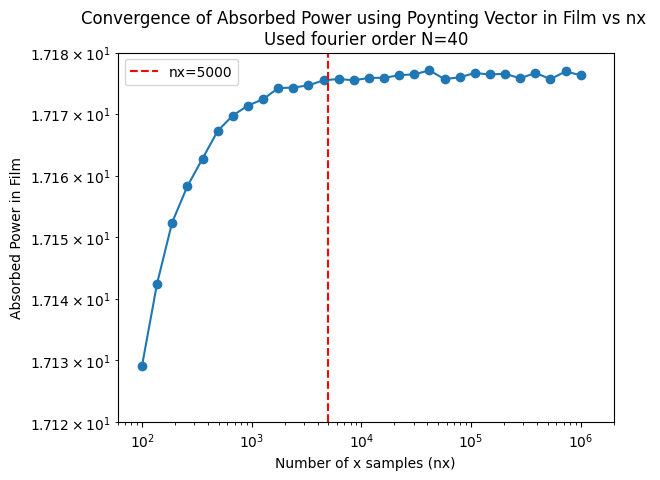

In [35]:
#Do a bunch of convergence checks by varying first geo.nx
P_absorbed_film_list = []
order_N = 40
nx_list = np.logspace(2,6,30,dtype=int)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[2]   # nm
A = torch.sum(params[:,0])
order = [order_N,0]
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)
for nx_test in tqdm(nx_list):
    torcwa.rcwa_geo.nx = nx_test
    torcwa.rcwa_geo.grid()

    sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[2])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[2])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
    
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(torcwa.rcwa_geo.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_cpu = torcwa.rcwa_geo.x.cpu().numpy()
    S_cpu = S_z.cpu().numpy()
    P_top = np.trapezoid(S_cpu[:,0], x_cpu)
    P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
    P_air = np.trapezoid(S_cpu[:,2], x_cpu)
    P_absorbed_film = P_top - P_bot
    P_absorbed_grating = P_air - P_top
    P_absorbed_film_list.append(P_absorbed_film)

plt.plot(nx_list, P_absorbed_film_list, marker='o')
plt.xlabel('Number of x samples (nx)')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
plt.xscale('log')
plt.vlines(x=5000,ymin=1.712*10, ymax=1.718*10, color='r', linestyle='--', label='nx=5000')
plt.ylim(1.712*10, 1.718*10)
plt.xlim(60,2e6)
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs nx \nUsed fourier order N={order_N}')
plt.legend()
plt.show()

In [36]:
P_absorbed_film_list[-1]

np.float32(17.176308)

  0%|          | 0/35 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed nx = 5000')

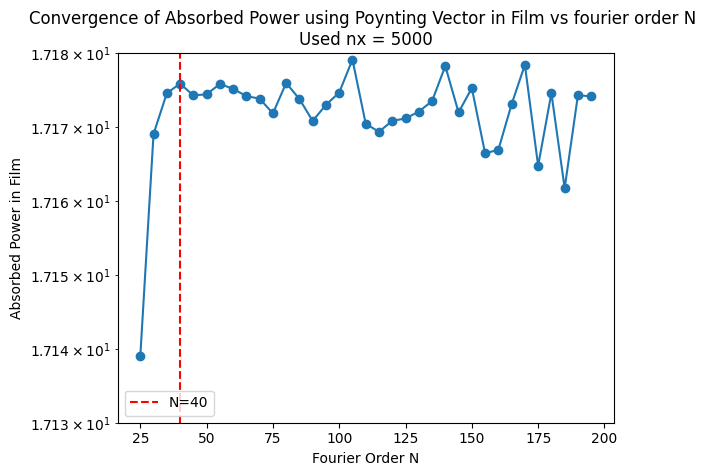

In [11]:
P_absorbed_film_list2 = []
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
Order_N_list = np.arange(25,200,5)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[2]   # nm
A = torch.sum(params[:,0])
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(0,device=sim._device, dtype=geo_dtype)
for order_N in tqdm(Order_N_list):
    order = [order_N,0]
    sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[2])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[2])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(torcwa.rcwa_geo.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_cpu = torcwa.rcwa_geo.x.cpu().numpy()
    S_cpu = S_z.cpu().numpy()
    P_top = np.trapezoid(S_cpu[:,0], x_cpu)
    P_bot = np.trapezoid(S_cpu[:,1], x_cpu)
    P_air = np.trapezoid(S_cpu[:,2], x_cpu)
    P_absorbed_film = P_top - P_bot
    P_absorbed_grating = P_air - P_top
    P_absorbed_film_list2.append(P_absorbed_film)

plt.plot(Order_N_list, P_absorbed_film_list2, marker='o')
plt.xlabel('Fourier Order N')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
plt.vlines(x=40,ymin=1.713e1,ymax=1.718e1, color='r', linestyle='--', label='N=40')
plt.ylim(1.713e1,1.718e1)
plt.legend()
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed nx = {torcwa.rcwa_geo.nx}')

In [10]:
P_absorbed_film_list2[-1]

np.float32(17.126078)

In [23]:
# sampling (increase for better convergence)
n_samples_list = [500, 1000, 2000, 3000]#, 4000, 5000, 7000, 10000]
P_absorbed_film_list3 = []


torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[2]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[2])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[2])
sim.solve_global_smatrix()
sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')


for n_samples in tqdm(n_samples_list):
    x_vol = torch.linspace(0, grating_period, n_samples, device=device, dtype=geo_dtype)          # (nx,)
    nz_film = n_samples
    sine_sample = get_sine_eps(x_vol,params=params,grating_period=grating_period,eps=si_eps[2])

    z_film = torch.linspace(A, A + h, nz_film, device=device, dtype=geo_dtype)   # film region


    # get fields
    [Ex_f, Ey_f, Ez_f], _ = sim.field_xz(x_vol, z_film, torch.tensor(0., device=device, dtype=geo_dtype))


    # squared field magnitude
    En2_f = torch.abs(Ex_f)**2 + torch.abs(Ey_f)**2 + torch.abs(Ez_f)**2   # (nx, nz_film)

    # angular freq (LH units: c=1 so freq = 1/λ; wavelength variable is in nm)
    omega = 2.0 * torch.pi / wavelength.to(device=device, dtype=geo_dtype)   # tensor scalar

    # film permittivity (complex) and imaginary part
    eps_film = si_eps[2].to(device=device, dtype=torch.complex64)
    eps_im_f = torch.imag(eps_film)   # scalar

    # local power density: 0.5 * omega * Im(eps) * |E|^2  (Heaviside-Lorentz units)
    pdens_f = 0.5 * omega * eps_im_f * En2_f    # (nx, nz_film)
    # integrate over x then z (per unit cell)
    Px_f = torch.trapz(pdens_f, x=x_vol, dim=0)        # (nz_film,)
    Pvol_f = torch.trapz(Px_f, x=z_film, dim=0)        # scalar

    # bring to CPU scalars for comparison
    Pvol_f_val = Pvol_f.cpu().item()
    P_absorbed_film_list3.append(Pvol_f_val)




  0%|          | 0/4 [00:00<?, ?it/s]

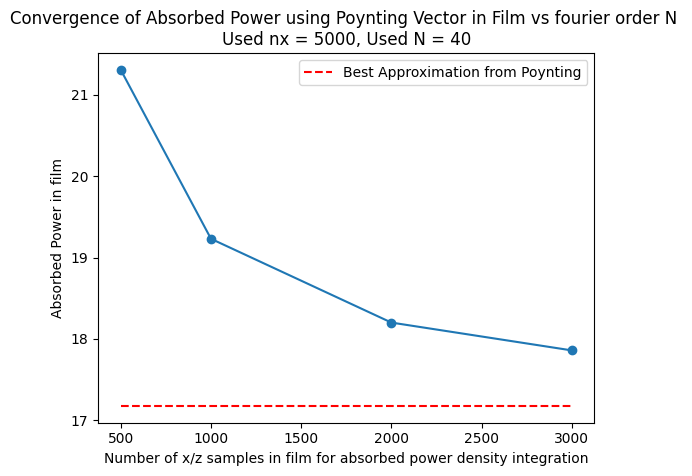

In [24]:
plt.plot(n_samples_list, P_absorbed_film_list3, marker='o')
plt.xlabel('Number of x/z samples in film for absorbed power density integration')
plt.ylabel('Absorbed Power in film')
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed nx = {torcwa.rcwa_geo.nx}, Used N = {order_N}')
plt.hlines(y=P_absorbed_film_list[-1], xmin=n_samples_list[0], xmax=n_samples_list[-1], color='r', linestyle='--', label='Best Approximation from Poynting')
plt.legend()
plt.show()

Text(0.5, 0.98, 'XZ-plane field distribution at wavelength = 370.0 nm and y = 0 nm \n polarization = E_x = 1.000, E_y = 0.000 \n incident angle = 0.0°, azimuthal angle = 0.0°')

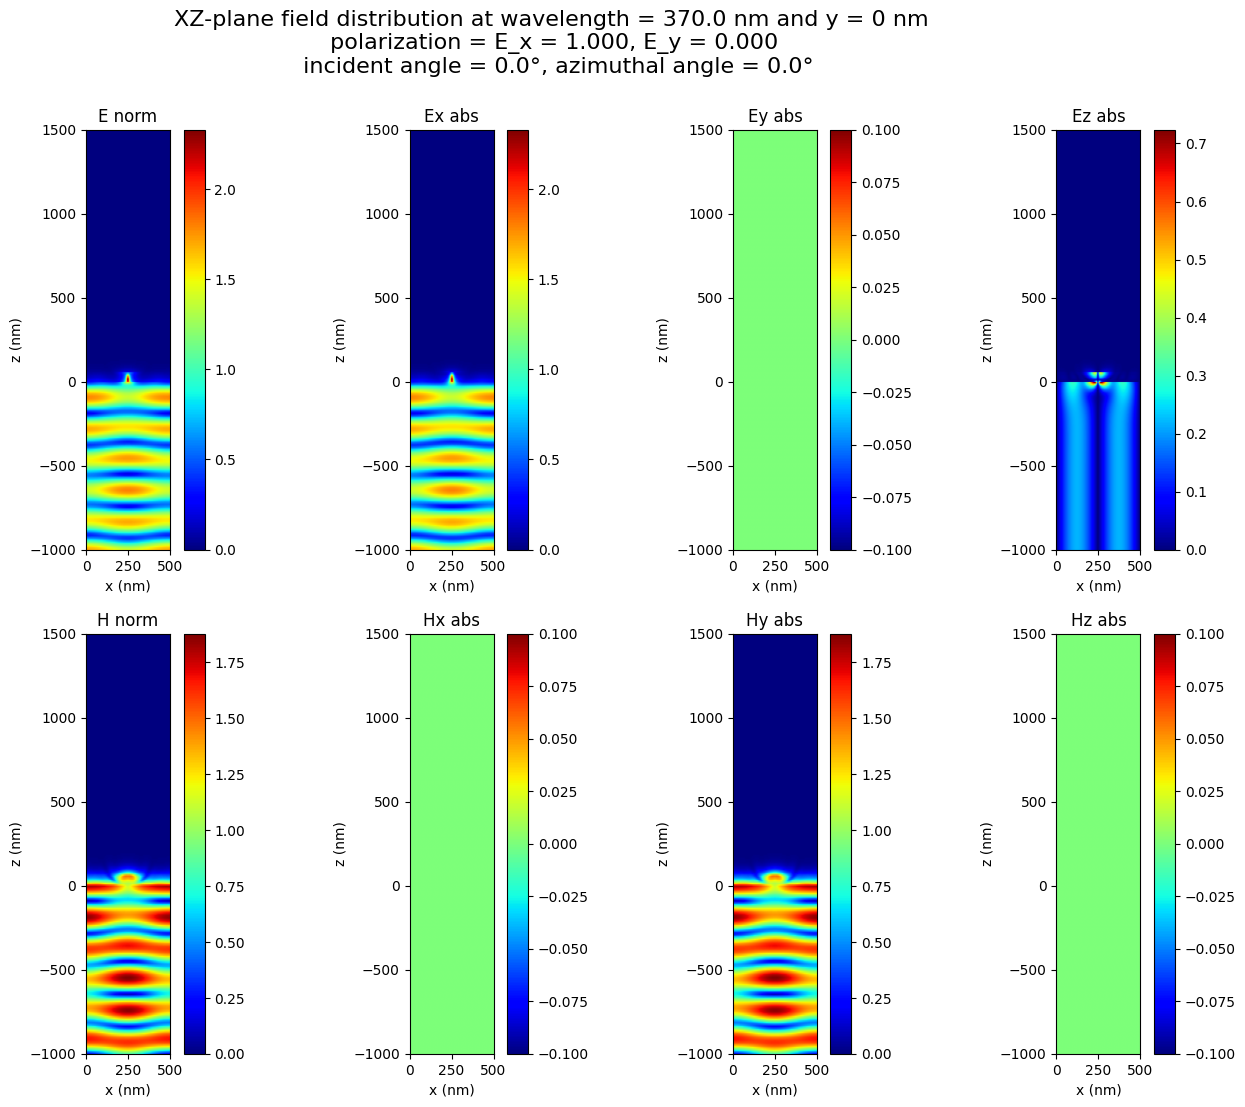

In [ ]:
# Define simulation again
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[2]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[2])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[2])
sim.solve_global_smatrix()
sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

# View XZ-plane fields
x_plot = torch.linspace(0, L[0], 300, device=device)
z_plot = torch.linspace(-h, 1.5*h, 300, device=device)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_plot,z_plot,torch.tensor(0))
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)
x_plot = x_plot.cpu()
z_plot = z_plot.cpu()

fig, axes = plt.subplots(figsize=(16,12),nrows=2,ncols=4)
im0 = axes[0,0].imshow(torch.transpose(Enorm,-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,0].set(title='E norm',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im1 = axes[0,1].imshow(torch.transpose(torch.abs(Ex),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,1].set(title='Ex abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im2 = axes[0,2].imshow(torch.transpose(torch.abs(Ey),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,2].set(title='Ey abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im3 = axes[0,3].imshow(torch.transpose(torch.abs(Ez),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[0,3].set(title='Ez abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im4 = axes[1,0].imshow(torch.transpose(Hnorm,-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,0].set(title='H norm',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im5 = axes[1,1].imshow(torch.transpose(torch.abs(Hx),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,1].set(title='Hx abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im6 = axes[1,2].imshow(torch.transpose(torch.abs(Hy),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,2].set(title='Hy abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
im7 = axes[1,3].imshow(torch.transpose(torch.abs(Hz),-2,-1).cpu(),cmap='jet',origin='lower',extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]])
axes[1,3].set(title='Hz abs',xlim=(0,L[0]),xlabel='x (nm)',ylim=(z_plot[0],z_plot[-1]),ylabel='z (nm)')
fig.colorbar(im0,ax=axes[0,0])
fig.colorbar(im1,ax=axes[0,1])
fig.colorbar(im2,ax=axes[0,2])
fig.colorbar(im3,ax=axes[0,3])
fig.colorbar(im4,ax=axes[1,0])
fig.colorbar(im5,ax=axes[1,1])
fig.colorbar(im6,ax=axes[1,2])
fig.colorbar(im7,ax=axes[1,3])
fig.suptitle(f'XZ-plane field distribution at wavelength = {wavelength} nm and y = 0 nm \n polarization = E_x = {polarization[0]:.3f}, E_y = {polarization[1]:.3f} \n incident angle = {inc_ang*180/np.pi:.1f}°, azimuthal angle = {azi_ang*180/np.pi:.1f}°', fontsize=16)

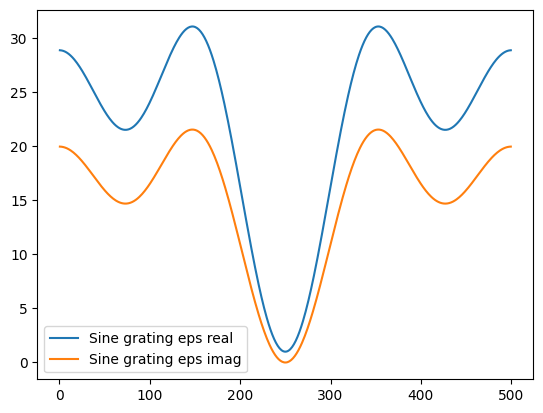

In [34]:
plt.plot(x_axis,sine_eps.real.cpu(),label='Sine grating eps real')
plt.plot(x_axis,sine_eps.imag.cpu(),label='Sine grating eps imag')
plt.legend()

In [35]:
# verify linearity of fields vs nonlinearity of norms
x_plot = torch.linspace(0, L[0], 300, device=device)
z_plot = torch.linspace(-h, 1.5*h, 300, device=device)
# get fields for x and y polarizations
sim.source_planewave(amplitude=[1.,0.], direction='forward', notation='xy')
[Ex_x, Ey_x, Ez_x], [Hx_x, Hy_x, Hz_x] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

sim.source_planewave(amplitude=[0.,1.], direction='forward', notation='xy')
[Ex_y, Ey_y, Ez_y], [Hx_y, Hy_y, Hz_y] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

# direct diagonal
a = 1/np.sqrt(2)
sim.source_planewave(amplitude=[a,a], direction='forward', notation='xy')
[Ex_d, Ey_d, Ez_d], [Hx_d, Hy_d, Hz_d] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

# check linear superposition of complex fields
Ex_sum = a*Ex_x + a*Ex_y
Ey_sum = a*Ey_x + a*Ey_y
Ez_sum = a*Ez_x + a*Ez_y

print('max abs error Ex:', torch.max(torch.abs(Ex_sum - Ex_d)).item())
print('max abs error Ey:', torch.max(torch.abs(Ey_sum - Ey_d)).item())
print('max abs error Ez:', torch.max(torch.abs(Ez_sum - Ez_d)).item())

# check norms (not linear)
Enorm_sum = 0.5*(torch.sqrt(torch.abs(Ex_x)**2 + torch.abs(Ey_x)**2 + torch.abs(Ez_x)**2) +
                 torch.sqrt(torch.abs(Ex_y)**2 + torch.abs(Ey_y)**2 + torch.abs(Ez_y)**2))
Enorm_diag = torch.sqrt(torch.abs(Ex_d)**2 + torch.abs(Ey_d)**2 + torch.abs(Ez_d)**2)
print('Note that the norms are not linearly additive:')
print('mean(Enorm_sum - Enorm_diag) =', torch.mean(Enorm_sum - Enorm_diag).item())

max abs error Ex: 3.6385998214427673e-07
max abs error Ey: 3.588674815091508e-07
max abs error Ez: 8.429369557916289e-08
Note that the norms are not linearly additive:
mean(Enorm_sum - Enorm_diag) = -0.0008930398034863174
